In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_BENCHMARK_10Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_10y"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_BENCHMARK_10Y_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_REWARD_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]
TRANSACTION_COST = 0.001

print("ASSETS:", ASSETS)
print("OUTPUTS_BENCHMARK_10Y_DIR:", OUTPUTS_BENCHMARK_10Y_DIR)

ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
OUTPUTS_BENCHMARK_10Y_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_10y


In [4]:
# ============================================================
# CELL 04 — Load 10Y tensor bundle
# ============================================================

bundle_10y = np.load(f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz", allow_pickle=True)

X_raw_10y = bundle_10y["X"].astype(np.float32)
y_10y = bundle_10y["y"].astype(np.float32)
dates_10y = pd.to_datetime(bundle_10y["dates"])
splits_10y = bundle_10y["splits"]

print("X_raw_10y:", X_raw_10y.shape)
print("y_10y:", y_10y.shape)
print("dates_10y:", dates_10y.shape)
print("splits_10y:", splits_10y.shape)
print("unique splits:", np.unique(splits_10y, return_counts=True))

X_raw_10y: (2476, 20, 5, 13)
y_10y: (2476, 5)
dates_10y: (2476,)
splits_10y: (2476,)
unique splits: (array(['test', 'train', 'val'], dtype='<U5'), array([ 501, 1472,  503]))


In [5]:
# ============================================================
# CELL 05 — Split 10Y data
# ============================================================

train_mask = (splits_10y == "train")
val_mask = (splits_10y == "val")
test_mask = (splits_10y == "test")

data_10y = {
    "train": {
        "X": X_raw_10y[train_mask],
        "y": y_10y[train_mask],
        "dates": np.array(dates_10y[train_mask].astype(str)),
    },
    "val": {
        "X": X_raw_10y[val_mask],
        "y": y_10y[val_mask],
        "dates": np.array(dates_10y[val_mask].astype(str)),
    },
    "test": {
        "X": X_raw_10y[test_mask],
        "y": y_10y[test_mask],
        "dates": np.array(dates_10y[test_mask].astype(str)),
    },
}

for split in ["train", "val", "test"]:
    print(split, data_10y[split]["X"].shape, data_10y[split]["y"].shape, data_10y[split]["dates"].shape)

train (1472, 20, 5, 13) (1472, 5) (1472,)
val (503, 20, 5, 13) (503, 5) (503,)
test (501, 20, 5, 13) (501, 5) (501,)


In [6]:
# ============================================================
# CELL 06 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.n_assets = self.X.shape[2]
        self.reset()

    def reset(self):
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(next_state=next_state, reward=float(reward), done=self.done, info=info)

In [7]:
# ============================================================
# CELL 07 — Benchmark helpers
# ============================================================

def sample_random_weights(n_assets: int) -> np.ndarray:
    x = np.random.rand(n_assets).astype(np.float32)
    x = x / x.sum()
    return x


def run_policy_rollout(env: PortfolioEnv, policy_name: str = "random") -> pd.DataFrame:
    env.reset()
    rows = []

    while True:
        if policy_name == "equal_weight":
            action = np.ones(env.n_assets, dtype=np.float32) / env.n_assets
        elif policy_name == "random":
            action = sample_random_weights(env.n_assets)
        else:
            raise ValueError("Unsupported policy_name")

        result = env.step(action)

        rows.append({
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        })

        if result.done:
            break

    return pd.DataFrame(rows)


def compute_metrics_from_rollout(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }

In [8]:
# ============================================================
# CELL 08 — Run equal-weight and random benchmarks on 10Y
# ============================================================

benchmark_rollouts_10y = {
    "Equal_Weight": {},
    "Random_Policy": {},
}

for split in ["train", "val", "test"]:
    env_eq = PortfolioEnv(
        X=data_10y[split]["X"],
        y=data_10y[split]["y"],
        dates=data_10y[split]["dates"],
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )
    env_rand = PortfolioEnv(
        X=data_10y[split]["X"],
        y=data_10y[split]["y"],
        dates=data_10y[split]["dates"],
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )

    benchmark_rollouts_10y["Equal_Weight"][split] = run_policy_rollout(env_eq, policy_name="equal_weight")
    benchmark_rollouts_10y["Random_Policy"][split] = run_policy_rollout(env_rand, policy_name="random")

    print(split,
          benchmark_rollouts_10y["Equal_Weight"][split].shape,
          benchmark_rollouts_10y["Random_Policy"][split].shape)

train (1472, 5) (1472, 5)
val (503, 5) (503, 5)
test (501, 5) (501, 5)


In [9]:
# ============================================================
# CELL 09 — Save equal-weight and random rollout files
# ============================================================

for split in ["train", "val", "test"]:
    benchmark_rollouts_10y["Equal_Weight"][split].to_csv(
        f"{OUTPUTS_BENCHMARK_10Y_DIR}/equal_weight_rollout_{split}_10y.csv",
        index=False
    )
    benchmark_rollouts_10y["Random_Policy"][split].to_csv(
        f"{OUTPUTS_BENCHMARK_10Y_DIR}/random_policy_rollout_{split}_10y.csv",
        index=False
    )

print("Saved equal-weight and random-policy rollout files for 10Y.")

Saved equal-weight and random-policy rollout files for 10Y.


In [10]:
# ============================================================
# CELL 10 — Compute equal-weight and random metrics
# ============================================================

benchmark_rows_core_10y = []

for model_name in ["Equal_Weight", "Random_Policy"]:
    for split in ["train", "val", "test"]:
        metrics = compute_metrics_from_rollout(benchmark_rollouts_10y[model_name][split])
        benchmark_rows_core_10y.append({
            "model": model_name,
            "split": split,
            **metrics,
        })

benchmark_core_metrics_10y = pd.DataFrame(benchmark_rows_core_10y)
display(benchmark_core_metrics_10y)

,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,Equal_Weight,train,1472,3.804671,2.804671,0.000998,0.013437,1.179592,-0.279886,0.000000,0.000000,0.000000
1,Equal_Weight,val,503,0.967653,-0.032347,0.000028,0.013666,0.032602,-0.259889,0.000000,0.000000,0.000000
2,Equal_Weight,test,501,1.724209,0.724209,0.001128,0.008996,1.991219,-0.102027,0.000000,0.000000,0.000000
3,Random_Policy,train,1472,1.755553,0.755553,0.001128,0.013784,1.298815,-0.291398,0.649812,0.956523,0.000650
4,Random_Policy,val,503,0.697936,-0.302064,0.000029,0.014267,0.032725,-0.422361,0.642516,0.323186,0.000643
5,Random_Policy,test,501,1.295984,0.295984,0.001205,0.009502,2.013152,-0.157984,0.641560,0.321422,0.000642


In [21]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=benchmark_core_metrics_10y)

https://docs.google.com/spreadsheets/d/1sUlcGPc5YuC2G17JPXyMxPUF_HXTrJAsweNtrA-qJdg/edit#gid=0


In [11]:
# ============================================================
# CELL 11 — Load buy-and-hold metrics and rollout files
# ============================================================

buyhold_metrics_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_metrics_10y.csv")

buyhold_rollouts_10y = {
    "train": pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_train_10y.csv"),
    "val": pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_val_10y.csv"),
    "test": pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_test_10y.csv"),
}

print("buyhold_metrics_10y:", buyhold_metrics_10y.shape)
display(buyhold_metrics_10y)

buyhold_metrics_10y: (3, 12)


,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,BuyHold_EqualWeight,train,1472,4.157526,3.157526,0.001070,0.014236,1.193000,-0.260812,0.0,0.0,0.0
1,BuyHold_EqualWeight,val,503,0.963545,-0.036455,0.000015,0.013328,0.017971,-0.270693,0.0,0.0,0.0
2,BuyHold_EqualWeight,test,501,1.780724,0.780724,0.001201,0.009848,1.935857,-0.113614,0.0,0.0,0.0


In [22]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=buyhold_metrics_10y)

https://docs.google.com/spreadsheets/d/1iX1G9h1ovQKyuv-ZWLWuVBhCPv1qT1TYCjq8R8Obhos/edit#gid=0


In [12]:
# ============================================================
# CELL 12 — Load trained model summaries and reward outputs
# ============================================================

def ensure_summary_has_cost_columns(summary_df: pd.DataFrame, model_dir: str) -> pd.DataFrame:
    summary_df = summary_df.copy()

    needed_cols = ["total_trading_cost", "avg_trading_cost"]
    if all(col in summary_df.columns for col in needed_cols):
        return summary_df

    cost_rows = []
    for split in ["train", "val", "test"]:
        rollout_path = f"{model_dir}/{split}_rollout_best.csv"
        rollout_df = pd.read_csv(rollout_path)

        total_trading_cost = float(rollout_df["trading_cost"].sum())
        avg_trading_cost = float(rollout_df["trading_cost"].mean())

        cost_rows.append({
            "split": split,
            "total_trading_cost": total_trading_cost,
            "avg_trading_cost": avg_trading_cost,
        })

    cost_df = pd.DataFrame(cost_rows)
    summary_df = summary_df.merge(cost_df, on="split", how="left")

    return summary_df


mlp_summary_10y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/mlp_ppo_10y/summary_metrics_best.csv")
lstm_summary_10y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/lstm_ppo_10y/summary_metrics_best.csv")

mlp_summary_10y = ensure_summary_has_cost_columns(
    mlp_summary_10y,
    f"{OUTPUTS_MODEL_DIR}/mlp_ppo_10y"
)
lstm_summary_10y = ensure_summary_has_cost_columns(
    lstm_summary_10y,
    f"{OUTPUTS_MODEL_DIR}/lstm_ppo_10y"
)

mlp_summary_10y["model"] = "MLP_PPO_10Y"
lstm_summary_10y["model"] = "LSTM_PPO_10Y"

reward_comparison_realistic_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_realistic_10y.csv")

print("mlp_summary_10y:", mlp_summary_10y.shape)
print("lstm_summary_10y:", lstm_summary_10y.shape)
print("reward_comparison_realistic_10y:", reward_comparison_realistic_10y.shape)

mlp_summary_10y: (3, 12)
lstm_summary_10y: (3, 12)
reward_comparison_realistic_10y: (6, 13)


In [13]:
# ============================================================
# CELL 13 — Build full supplementary benchmark table
# ============================================================

transformer_table_10y = reward_comparison_realistic_10y[[
    "model",
    "split",
    "n_steps",
    "final_portfolio_value",
    "cumulative_return",
    "avg_daily_return",
    "daily_volatility",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
    "avg_trading_cost",
]].copy()

supp_benchmark_10y = pd.concat([
    benchmark_core_metrics_10y,
    buyhold_metrics_10y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
    mlp_summary_10y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
    lstm_summary_10y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
    transformer_table_10y,
], axis=0, ignore_index=True)

model_order = [
    "Equal_Weight",
    "BuyHold_EqualWeight",
    "Random_Policy",
    "MLP_PPO_10Y",
    "LSTM_PPO_10Y",
    "Transformer10Y_CostAwareTrain",
    "Transformer10Y_NoCostTrain",
]
split_order = ["train", "val", "test"]

supp_benchmark_10y["model"] = pd.Categorical(supp_benchmark_10y["model"], categories=model_order, ordered=True)
supp_benchmark_10y["split"] = pd.Categorical(supp_benchmark_10y["split"], categories=split_order, ordered=True)

supp_benchmark_10y = supp_benchmark_10y.sort_values(["split", "model"]).reset_index(drop=True)
display(supp_benchmark_10y)

,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,Equal_Weight,train,1472,3.804671,2.804671,0.000998,0.013437,1.179592,-0.279886,0.000000,0.000000,0.000000
1,BuyHold_EqualWeight,train,1472,4.157526,3.157526,0.001070,0.014236,1.193000,-0.260812,0.000000,0.000000,0.000000
2,Random_Policy,train,1472,1.755553,0.755553,0.001128,0.013784,1.298815,-0.291398,0.649812,0.956523,0.000650
3,MLP_PPO_10Y,train,1472,2.822646,1.822646,0.001100,0.013724,1.272530,-0.283306,0.300568,0.442436,0.000301
4,LSTM_PPO_10Y,train,1472,3.217416,2.217416,0.001046,0.013833,1.200290,-0.268693,0.155929,0.229527,0.000156
5,Transformer10Y_CostAwareTrain,train,1472,3.412676,2.412676,0.001219,0.014081,1.374202,-0.298393,0.285127,0.419706,0.000285
6,Transformer10Y_NoCostTrain,train,1472,3.461081,2.461081,0.001076,0.013847,1.233769,-0.286193,0.136346,0.200701,0.000136
7,Equal_Weight,val,503,0.967653,-0.032347,0.000028,0.013666,0.032602,-0.259889,0.000000,0.000000,0.000000
8,BuyHold_EqualWeight,val,503,0.963545,-0.036455,0.000015,0.013328,0.017971,-0.270693,0.000000,0.000000,0.000000
9,Random_Policy,val,503,0.697936,-0.302064,0.000029,0.014267,0.032725,-0.422361,0.642516,0.323186,0.000643


In [23]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=supp_benchmark_10y)

https://docs.google.com/spreadsheets/d/1q0fQZy2-jwh0BWhtw9ihqDwcTxqoSGVCXiX7SXHhQRM/edit#gid=0


In [14]:
# ============================================================
# CELL 14 — Build 10Y test leaderboard
# ============================================================

leaderboard_test_10y = (
    supp_benchmark_10y[supp_benchmark_10y["split"] == "test"][
        ["model", "cumulative_return", "sharpe_approx", "max_drawdown", "avg_turnover", "total_trading_cost"]
    ]
    .sort_values("cumulative_return", ascending=False)
    .reset_index(drop=True)
)

leaderboard_test_10y["rank_test_cumret"] = np.arange(1, len(leaderboard_test_10y) + 1)
display(leaderboard_test_10y)

,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rank_test_cumret
0,BuyHold_EqualWeight,0.780724,1.935857,-0.113614,0.000000,0.000000,1
1,Equal_Weight,0.724209,1.991219,-0.102027,0.000000,0.000000,2
2,Transformer10Y_NoCostTrain,0.645066,1.904087,-0.110084,0.146739,0.073516,3
3,MLP_PPO_10Y,0.636315,2.213623,-0.104044,0.227882,0.114169,4
4,LSTM_PPO_10Y,0.602773,1.876290,-0.107737,0.146698,0.073496,5
5,Transformer10Y_CostAwareTrain,0.562732,2.057607,-0.123749,0.271854,0.136199,6
6,Random_Policy,0.295984,2.013152,-0.157984,0.641560,0.321422,7


In [24]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=leaderboard_test_10y)

https://docs.google.com/spreadsheets/d/17fZvQlHY7-TUaOZzTWsb9w0kj5p_lTkDW5GG2KeUZk8/edit#gid=0


In [15]:
# ============================================================
# CELL 15 — Save full supplementary tables
# ============================================================

supp_benchmark_10y.to_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_benchmark_metrics_10y.csv", index=False)
leaderboard_test_10y.to_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_leaderboard_test_10y.csv", index=False)

print("Saved full supplementary 10Y tables.")

Saved full supplementary 10Y tables.


In [16]:
# ============================================================
# CELL 16 — Load test rollout files for plot
# ============================================================

eq_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/equal_weight_rollout_test_10y.csv")
buyhold_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_test_10y.csv")
rand_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/random_policy_rollout_test_10y.csv")

mlp_test_10y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/mlp_ppo_10y/test_rollout_best.csv")
lstm_test_10y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/lstm_ppo_10y/test_rollout_best.csv")
costaware_test_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/costaware_train_test_rollout_realistic_10y.csv")
nocost_test_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/nocost_train_test_rollout_realistic_10y.csv")

print("Loaded all 10Y test rollout files.")

Loaded all 10Y test rollout files.


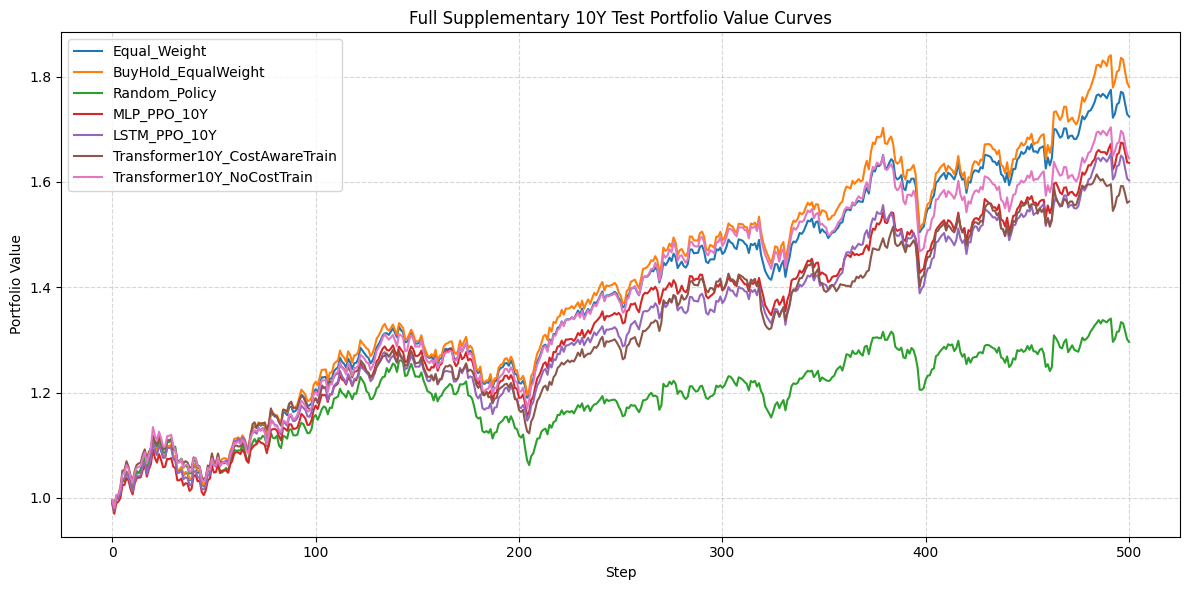

In [17]:
# ============================================================
# CELL 17 — Plot full supplementary 10Y test curves
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(eq_test_10y["portfolio_value"].values, label="Equal_Weight")
plt.plot(buyhold_test_10y["portfolio_value"].values, label="BuyHold_EqualWeight")
plt.plot(rand_test_10y["portfolio_value"].values, label="Random_Policy")
plt.plot(mlp_test_10y["portfolio_value"].values, label="MLP_PPO_10Y")
plt.plot(lstm_test_10y["portfolio_value"].values, label="LSTM_PPO_10Y")
plt.plot(costaware_test_10y["portfolio_value"].values, label="Transformer10Y_CostAwareTrain")
plt.plot(nocost_test_10y["portfolio_value"].values, label="Transformer10Y_NoCostTrain")

plt.title("Full Supplementary 10Y Test Portfolio Value Curves")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# CELL 18 — Build interpretation summary
# ============================================================

top_10y = leaderboard_test_10y.iloc[0]
top_learned_10y = leaderboard_test_10y[
    leaderboard_test_10y["model"].isin([
        "MLP_PPO_10Y",
        "LSTM_PPO_10Y",
        "Transformer10Y_CostAwareTrain",
        "Transformer10Y_NoCostTrain",
    ])
].iloc[0]

supp_interpretation_10y = pd.DataFrame([
    {
        "topic": "Supplementary 10Y Benchmark",
        "finding": f"Best overall 10Y test result was {top_10y['model']}",
        "evidence": f"Test cumulative return = {top_10y['cumulative_return']:.6f}",
    },
    {
        "topic": "Supplementary 10Y Learned Models",
        "finding": f"Best learned 10Y test result was {top_learned_10y['model']}",
        "evidence": f"Test cumulative return = {top_learned_10y['cumulative_return']:.6f}",
    },
    {
        "topic": "Supplementary 10Y Passive Baselines",
        "finding": "Equal-weight and buy-and-hold were both highly competitive passive benchmarks",
        "evidence": "Observed in the 10Y test leaderboard and portfolio value curves",
    },
    {
        "topic": "Supplementary 10Y Reward",
        "finding": "No-cost-trained Transformer outperformed cost-aware-trained Transformer under realistic 10Y evaluation",
        "evidence": "Observed in the 10Y test leaderboard and reward comparison outputs",
    },
])

display(supp_interpretation_10y)

,topic,finding,evidence
0,Supplementary 10Y Benchmark,Best overall 10Y test result was BuyHold_Equal...,Test cumulative return = 0.780724
1,Supplementary 10Y Learned Models,Best learned 10Y test result was Transformer10...,Test cumulative return = 0.645066
2,Supplementary 10Y Passive Baselines,Equal-weight and buy-and-hold were both highly...,Observed in the 10Y test leaderboard and portf...
3,Supplementary 10Y Reward,No-cost-trained Transformer outperformed cost-...,Observed in the 10Y test leaderboard and rewar...


In [25]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=supp_interpretation_10y)

https://docs.google.com/spreadsheets/d/1AnhXZmouK6Kkz4V4R69cEd6Eiiv6s9R0_HbckPG1qTI/edit#gid=0


In [19]:
# ============================================================
# CELL 19 — Save interpretation summary
# ============================================================

supp_interpretation_10y.to_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_interpretation_10y.csv", index=False)
print("Saved supplementary interpretation 10Y.")

Saved supplementary interpretation 10Y.


In [20]:
# ============================================================
# CELL 20 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_benchmark_metrics_10y.csv",
    f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_leaderboard_test_10y.csv",
    f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_interpretation_10y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("All updated 10Y benchmark notebook checks passed.")

All updated 10Y benchmark notebook checks passed.
